# Experiment 2: paired seed outcomes

Thirty-two additional checkpoints repeat the full-update reference (LR 3e-7, L2-SP 0.003, one sample) with training seed 43. Their seed-42 counterparts come from experiment 1. Dataset partitions, monitoring randomness and evaluation folds are fixed. Two seeds provide a paired sensitivity check at this recipe, not a variance estimate for the full grid.

## 0. Evidence and scope

DATA manifests describe progress. Detailed trajectories and benchmark predictions come from project storage. Missing evidence is unavailable, never a zero effect.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
REPO = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'pyproject.toml').is_file())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
from src.visualize import style, campaign as cp, publication as pub, diagnostics as dg
from src.visualize import comparisons as cmp, pilots as pv, optimization as op
from src.visualize.figures import FigureSaver
from src.visualize.inputs import source_description
style.apply()
sink = FigureSaver('experiment2/02_results')
report = cp.NotebookReport('Experiment 2: paired seed outcomes', sink=sink)
print(source_description())
report.add('0. Evidence and scope', source_description())

DATA: no external source selected.
Project: no external source selected.
Missing project records are unavailable evidence, not zero effects or failed training.


## 1. Checkpoint and benchmark coverage

The final benchmark holds the CPT weights fixed and supplies labeled context from each outer training fold. Thresholds and calibrators use inner validation rows; outer test labels do not select them.

In [2]:
main = {track: cmp.reference_campaign(cp.load_campaign(1, track)) for track in ('pd', 'lgd')}
repeat = {track: cp.load_campaign(2, track) for track in ('pd', 'lgd')}
for track in ('pd', 'lgd'):
    report.table(track.upper()+' seed 42 reference evidence', pub.availability(main[track]))
    report.table(track.upper()+' seed 43 evidence', pub.availability(repeat[track]))
    report.table(track.upper()+' seed 42 benchmark coverage', cmp.benchmark_coverage(main[track]))
    report.table(track.upper()+' seed 43 benchmark coverage', cmp.benchmark_coverage(repeat[track]))
report.add('1. Checkpoint and benchmark coverage', 'Five complete outer folds and the matching untuned reference are required for each benchmark effect. Evaluation seed 99 is shared; training seed changes only continued pretraining.')

C:\Users\U0152019\PhD Documents\Projects\3. CreditPFN\CreditPFN\src\visualize\eval_viz.py:250: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  full = pd.concat(frames, ignore_index=True)


C:\Users\U0152019\PhD Documents\Projects\3. CreditPFN\CreditPFN\src\visualize\eval_viz.py:250: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  full = pd.concat(frames, ignore_index=True)


,evidence,records,origin
0,Planned trials,16,Config; not scheduler state
1,Completed trials,16,DATA manifests
2,Epoch rows,12592,Project training diagnostics
3,Milestone rows,96,Project trajectory diagnostics
4,Benchmark folds,100,Project final evaluation


,evidence,records,origin
0,Planned trials,16,Config; not scheduler state
1,Completed trials,16,DATA manifests
2,Epoch rows,12592,Project training diagnostics
3,Milestone rows,96,Project trajectory diagnostics
4,Benchmark folds,0,Project final evaluation


,domain,base,planned_checkpoints,completed_checkpoints,paired_five_fold_comparisons,paired_datasets
0,credit,TabICLv2,4,4,0,0
1,credit,TabPFN v2,4,4,0,0
2,credit,TabPFN v2.6,4,4,0,0
3,credit,TabPFN v3,4,4,0,0
4,ood,TabICLv2,4,4,0,0
5,ood,TabPFN v2,4,4,0,0
6,ood,TabPFN v2.6,4,4,0,0
7,ood,TabPFN v3,4,4,0,0


,domain,base,planned_checkpoints,completed_checkpoints,paired_five_fold_comparisons,paired_datasets
0,credit,TabICLv2,4,4,0,0
1,credit,TabPFN v2,4,4,0,0
2,credit,TabPFN v2.6,4,4,0,0
3,credit,TabPFN v3,4,4,0,0
4,ood,TabICLv2,4,4,0,0
5,ood,TabPFN v2,4,4,0,0
6,ood,TabPFN v2.6,4,4,0,0
7,ood,TabPFN v3,4,4,0,0


,evidence,records,origin
0,Planned trials,16,Config; not scheduler state
1,Completed trials,16,DATA manifests
2,Epoch rows,26688,Project training diagnostics
3,Milestone rows,96,Project trajectory diagnostics
4,Benchmark folds,130,Project final evaluation


,evidence,records,origin
0,Planned trials,16,Config; not scheduler state
1,Completed trials,16,DATA manifests
2,Epoch rows,26688,Project training diagnostics
3,Milestone rows,96,Project trajectory diagnostics
4,Benchmark folds,0,Project final evaluation


,domain,base,planned_checkpoints,completed_checkpoints,paired_five_fold_comparisons,paired_datasets
0,credit,TabICLv2,4,4,0,0
1,credit,TabPFN v2,4,4,0,0
2,credit,TabPFN v2.6,4,4,0,0
3,credit,TabPFN v3,4,4,0,0
4,ood,TabICLv2,4,4,0,0
5,ood,TabPFN v2,4,4,0,0
6,ood,TabPFN v2.6,4,4,0,0
7,ood,TabPFN v3,4,4,0,0


,domain,base,planned_checkpoints,completed_checkpoints,paired_five_fold_comparisons,paired_datasets
0,credit,TabICLv2,4,4,0,0
1,credit,TabPFN v2,4,4,0,0
2,credit,TabPFN v2.6,4,4,0,0
3,credit,TabPFN v3,4,4,0,0
4,ood,TabICLv2,4,4,0,0
5,ood,TabPFN v2,4,4,0,0
6,ood,TabPFN v2.6,4,4,0,0
7,ood,TabPFN v3,4,4,0,0


## 2. Final benchmark seed comparison

Compare held-out credit transfer and the fixed non-credit panel. All four model bases appear together; dataset differences remain visible.

In [3]:
for track in ('pd','lgd'):
    cp.show(sink, cmp.plot_seed_endpoints(main[track], repeat[track], benchmark=True), track=track)
report.add('2. Final benchmark seed comparison', 'Pair partition/dataset observations before averaging. Non-credit datasets require all four paired training partitions; no incomplete counterpart is replaced by another fold.')

No measurements available for this section yet.
No measurements available for this section yet.


## 3. Probability quality, calibration and error metrics

Use the same pairing for discrimination, F1 and calibration diagnostics in PD, and error metrics in LGD. Positive contrasts favor seed 43. Metric scales differ and are not combined into one score.

In [4]:
for track in ('pd','lgd'):
    for label, frame in cmp.metric_tables(repeat[track], main=main[track]).items():
        report.table(track.upper()+' '+label, frame)
    report.table(track.upper()+' seed 43 absolute benchmark scores', cmp.benchmark_scores(repeat[track]))
report.add('3. Probability quality, calibration and error metrics', 'Brier score and log loss assess probability quality; ECE is a bin-dependent calibration diagnostic. F1 thresholds and Platt/isotonic calibration use validation rows only. Unsupported or incomplete metrics stay absent. Classical and untuned model scores provide context.')

""


""


""


""


""


""


""


""


## 4. Endpoint monitors as supporting evidence

The 10,000-update monitors use smaller fixed row samples and ensembles. Show them separately from the final benchmark.

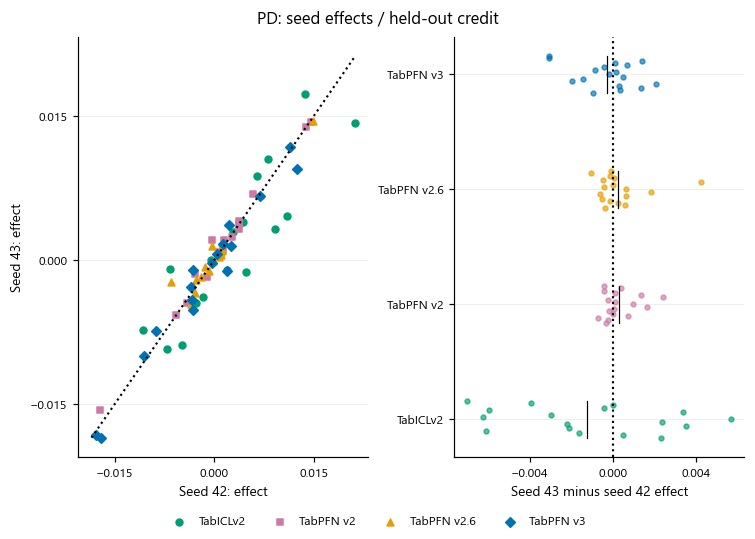

PD. Held-out credit: 10000-update monitor effects for the predefined full-update reference, LR 3e-7 and L2-SP 0.003. Effects are Increase in AUC (+ better) relative to each model's original weights. Observations match on dataset and training partition before averaging. Each non-credit dataset requires all four matched partitions; credit datasets have one held-out partition. Points are datasets and vertical marks in the difference panel are dataset means. Positive differences favor seed 43; two seeds do not estimate a general seed distribution.

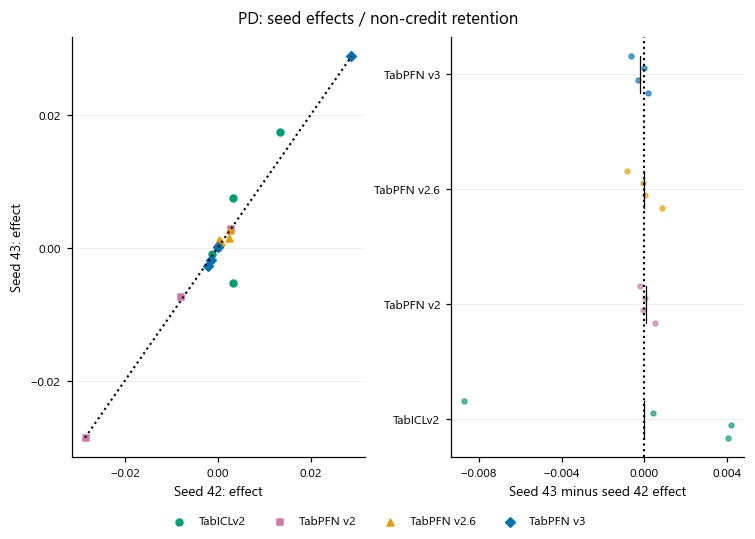

PD. Non-credit retention: 10000-update monitor effects for the predefined full-update reference, LR 3e-7 and L2-SP 0.003. Effects are Increase in AUC (+ better) relative to each model's original weights. Observations match on dataset and training partition before averaging. Each non-credit dataset requires all four matched partitions; credit datasets have one held-out partition. Points are datasets and vertical marks in the difference panel are dataset means. Positive differences favor seed 43; two seeds do not estimate a general seed distribution.

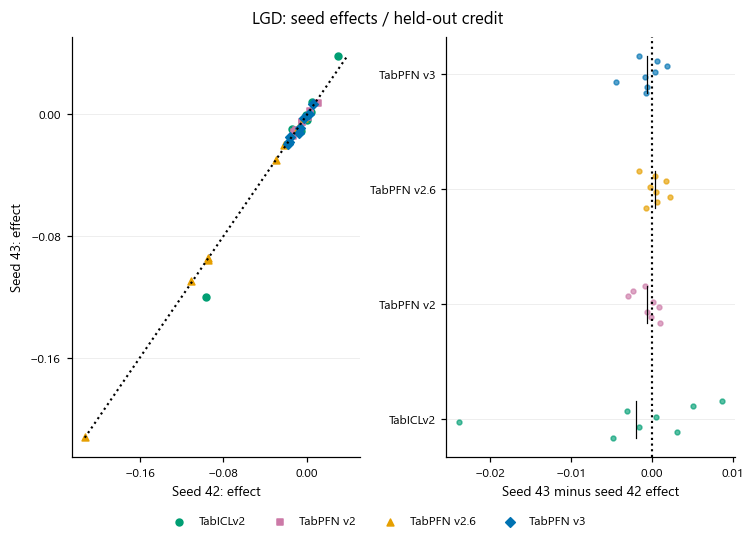

LGD. Held-out credit: 10000-update monitor effects for the predefined full-update reference, LR 3e-7 and L2-SP 0.003. Effects are Fractional RMSE reduction (+ better) relative to each model's original weights. Observations match on dataset and training partition before averaging. Each non-credit dataset requires all four matched partitions; credit datasets have one held-out partition. Points are datasets and vertical marks in the difference panel are dataset means. Positive differences favor seed 43; two seeds do not estimate a general seed distribution.

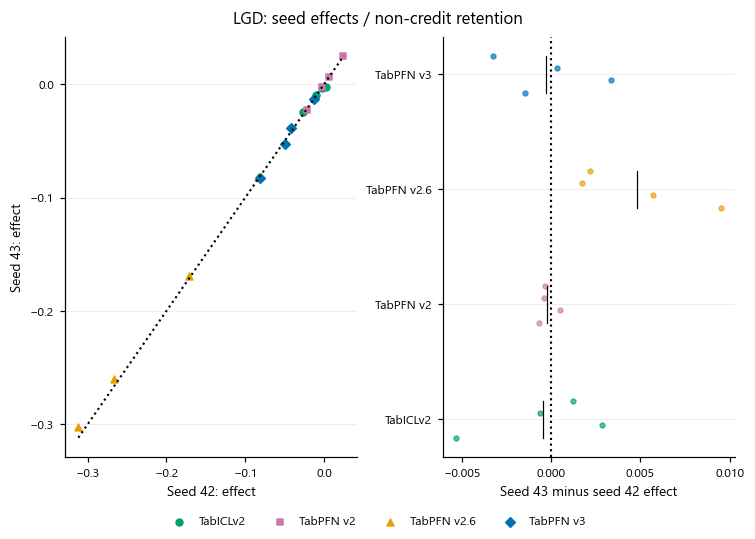

LGD. Non-credit retention: 10000-update monitor effects for the predefined full-update reference, LR 3e-7 and L2-SP 0.003. Effects are Fractional RMSE reduction (+ better) relative to each model's original weights. Observations match on dataset and training partition before averaging. Each non-credit dataset requires all four matched partitions; credit datasets have one held-out partition. Points are datasets and vertical marks in the difference panel are dataset means. Positive differences favor seed 43; two seeds do not estimate a general seed distribution.

In [5]:
for track in ('pd','lgd'):
    cp.show(sink, cmp.plot_seed_endpoints(main[track], repeat[track]), track=track)
report.add('4. Endpoint monitors as supporting evidence', 'Monitor and benchmark figures have distinct identities, captions and data sources. Their score differences are not estimates of seed sensitivity.')

## 5. Cost and scope of inference

Interpret seed effects at the predeclared recipe rather than selecting whichever seed performs best.

In [6]:
for track in ('pd','lgd'):
    report.table(track.upper()+' matched seed costs', cmp.seed_costs(main[track], repeat[track]))
report.add('5. Cost and scope of inference', 'Two seeds do not establish robustness elsewhere in the grid. Overlapping training partitions and repeated non-credit tables are not independent dataset replications.')

,base,learning_rate,l2sp_lambda,frozen,sampling,partition,gpu_hours_seed42,rows_seen_seed42,sec_per_step_seed42,peak_gpu_gb_seed42,final_drift_seed42,gpu_hours_seed43,rows_seen_seed43,sec_per_step_seed43,peak_gpu_gb_seed43,final_drift_seed43
0,TabPFN v2,3.000000e-07,0.003,False,one_sample,0,1.454035,84373151,0.523453,181.083,0.001053,1.462365,84373151,0.526452,181.083,0.001048
1,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,0,1.257469,91297151,0.452689,128.420,0.000922,1.266915,91297151,0.456089,128.420,0.000917
2,TabPFN v3,3.000000e-07,0.003,False,one_sample,0,1.558402,195157151,0.561025,121.097,0.001484,1.544833,195157151,0.556140,121.097,0.001486
3,TabICLv2,3.000000e-07,0.003,False,one_sample,0,1.723669,195157151,0.620521,27.121,0.001127,1.742087,195157151,0.627151,27.121,0.001129
4,TabPFN v2,3.000000e-07,0.003,False,one_sample,1,1.509654,81431410,0.543475,181.083,0.001126,1.498518,81431410,0.539467,181.083,0.001122
5,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,1,1.267968,87585410,0.456468,128.420,0.000949,1.255736,87585410,0.452065,128.420,0.000963
6,TabPFN v3,3.000000e-07,0.003,False,one_sample,1,1.528158,179895410,0.550137,121.097,0.001504,1.513583,179895410,0.544890,121.097,0.001509
7,TabICLv2,3.000000e-07,0.003,False,one_sample,1,1.675400,179895410,0.603144,27.121,0.001188,1.679518,179895410,0.604627,27.121,0.001268
8,TabPFN v2,3.000000e-07,0.003,False,one_sample,2,1.326894,74887937,0.477682,181.083,0.001111,1.341781,74896712,0.483041,181.083,0.001097
9,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,2,1.148323,80721937,0.413396,128.420,0.000877,1.161091,80731712,0.417993,128.420,0.000883


,base,learning_rate,l2sp_lambda,frozen,sampling,partition,gpu_hours_seed42,rows_seen_seed42,sec_per_step_seed42,peak_gpu_gb_seed42,final_drift_seed42,gpu_hours_seed43,rows_seen_seed43,sec_per_step_seed43,peak_gpu_gb_seed43,final_drift_seed43
0,TabPFN v2,3.000000e-07,0.003,False,one_sample,0,0.617954,46113629,0.222463,71.895,0.000655,0.624287,46117910,0.224743,71.895,0.000659
1,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,0,0.868460,49446629,0.312646,89.881,0.004031,0.869703,49451910,0.313093,89.881,0.004025
2,TabPFN v3,3.000000e-07,0.003,False,one_sample,0,0.673445,82784961,0.242440,46.801,0.002386,0.689529,82795244,0.248231,46.801,0.002388
3,TabICLv2,3.000000e-07,0.003,False,one_sample,0,0.642614,82784961,0.231341,10.998,0.001393,0.642462,82795244,0.231286,10.998,0.001385
4,TabPFN v2,3.000000e-07,0.003,False,one_sample,1,0.444908,24755261,0.160167,79.403,0.000688,0.448634,24750304,0.161508,79.403,0.000690
5,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,1,0.550625,24755261,0.198225,72.120,0.004137,0.545841,24750304,0.196503,72.120,0.004142
6,TabPFN v3,3.000000e-07,0.003,False,one_sample,1,0.430310,24755261,0.154912,21.665,0.002378,0.442364,24750304,0.159251,21.665,0.002418
7,TabICLv2,3.000000e-07,0.003,False,one_sample,1,0.304217,24755261,0.109518,4.596,0.001245,0.304017,24750304,0.109446,4.596,0.001249
8,TabPFN v2,3.000000e-07,0.003,False,one_sample,2,0.701201,47722903,0.252432,79.403,0.000686,0.699197,47715524,0.251711,79.403,0.000688
9,TabPFN v2.6,3.000000e-07,0.003,False,one_sample,2,0.898289,51056903,0.323384,89.881,0.003871,0.912374,51048524,0.328455,89.881,0.003883


## Complete text summary

All displayed numerical values and captions, in section order.

In [7]:
print(report.summary(sink))

Experiment 2: paired seed outcomes

0. Evidence and scope
DATA: no external source selected.
Project: no external source selected.
Missing project records are unavailable evidence, not zero effects or failed training.

1. Checkpoint and benchmark coverage
Five complete outer folds and the matching untuned reference are required for each benchmark effect. Evaluation seed 99 is shared; training seed changes only continued pretraining.

Table: PD seed 42 reference evidence
           evidence  records                          origin
0    Planned trials       16     Config; not scheduler state
1  Completed trials       16                  DATA manifests
2        Epoch rows    12592    Project training diagnostics
3    Milestone rows       96  Project trajectory diagnostics
4   Benchmark folds      100        Project final evaluation

Table: PD seed 43 evidence
           evidence  records                          origin
0    Planned trials       16     Config; not scheduler state
1  Comple